
# Visualizing and Auditing Excel Models with Python

This notebook demonstrates how to **inspect and audit Excel models programmatically**.

Excel spreadsheets behave like small programs:

- cells hold values
- formulas define logic
- dependencies propagate calculations

Because of this, we can model a spreadsheet as a **directed dependency graph**.

By extracting those relationships we can:

• understand how the model works  
• detect structural issues  
• highlight modeling violations  
• identify disconnected calculations  

This notebook walks through the full process step‑by‑step.


## Install libraries if needed

In [1]:

# openpyxl   -> read Excel workbook structure
# networkx   -> build dependency graphs
# matplotlib -> visualize the graph

# Uncomment if needed:
# !pip install openpyxl networkx matplotlib


## Import libraries

In [2]:

import openpyxl
import networkx as nx
import matplotlib.pyplot as plt
import re

from openpyxl.utils.cell import coordinate_from_string, column_index_from_string
from openpyxl.utils import get_column_letter



## Load workbook

Python reads the workbook as **structured data** rather than executing calculations.

This allows us to inspect formulas and relationships safely.


In [3]:

file = "demo_financial_model2.xlsx"

# data_only=False ensures formulas remain visible
wb = openpyxl.load_workbook(file, data_only=False)

print("Sheets in workbook:")
print(wb.sheetnames)


Sheets in workbook:
['Inputs', 'Calculations', 'Outputs']


## Resolve named ranges

Formulas can reference **named ranges** (e.g. `SUM(profits)`) instead of explicit sheet/cell addresses.

We extract all defined names from the workbook and build a lookup so these references can be resolved to real cell addresses when building the dependency graph.

In [ ]:
# Build a lookup: named_range_name -> list of "Sheet!Cell" references
# This is needed because formulas may use names like SUM(profits) instead of SUM(Calculations!E2:E4)
named_range_cells = {}

for name in wb.defined_names:
    defn = wb.defined_names[name]
    cells = []
    try:
        for sheet_name, cell_range in defn.destinations:
            clean_range = cell_range.replace("$", "")
            if ":" in clean_range:
                start, end = clean_range.split(":")
                cells.extend(expand_range(sheet_name, start, end))
            else:
                cells.append(f"{sheet_name}!{clean_range}")
    except Exception as e:
        print(f"Warning: could not resolve named range '{name}': {e}")
    named_range_cells[name] = cells

print("Named ranges found:")
for name, refs in named_range_cells.items():
    print(f"  {name!r} -> {refs}")


## Detect hardcoded constants

Well‑structured Excel models usually follow:

Inputs → Calculations → Outputs

Constants should generally appear in the **Inputs sheet**, not inside calculations.

This step flags numeric values appearing outside the Inputs sheet.


In [4]:
# Initialize an empty set to store locations of hardcoded cells
hardcoded_cells = set()
# Define which sheets are considered input sheets (these will be excluded from hardcoded cell detection)
input_sheets = ["Inputs"]

# Iterate through each sheet in the workbook
for sheet in wb.sheetnames:
    
    # Get the worksheet object for the current sheet
    ws = wb[sheet]
    
    # Iterate through each row in the worksheet
    for row in ws.iter_rows():
        # Iterate through each cell in the row
        for cell in row:
            
            # Check if the cell contains a numeric value
            # openpyxl uses 'n' for numeric cell types
            if cell.data_type == "n":
                
                # If the sheet is not in the input_sheets list and the cell has a value
                if sheet not in input_sheets and cell.value is not None:
                    
                    # Create a location string in the format "SheetName!CellReference"
                    location = f"{sheet}!{cell.coordinate}"
                    # Add this location to our set of hardcoded cells
                    hardcoded_cells.add(location)

# Display the results
print("Potential hardcoded cells:")
print(hardcoded_cells)

Potential hardcoded cells:
{'Calculations!A2', 'Calculations!A4', 'Calculations!A3', 'Calculations!C2'}



## Expand Excel ranges

Formulas often reference ranges such as:

`SUM(E2:E4)`

To properly build dependency graphs we expand ranges into individual cells.


In [5]:

def expand_range(sheet, start, end):
    """
    Expands a cell range into individual cell references.
    
    Args:
        sheet: Name of the worksheet
        start: Starting cell reference (e.g. 'A1')
        end: Ending cell reference (e.g. 'B3')
        
    Returns:
        List of fully qualified cell references (e.g. ['Sheet1!A1', 'Sheet1!A2', ...])
    """
    # Split the cell references into column letters and row numbers
    col1, row1 = coordinate_from_string(start)
    col2, row2 = coordinate_from_string(end)

    # Convert column letters to numeric indices
    col1_i = column_index_from_string(col1)
    col2_i = column_index_from_string(col2)

    cells = []

    # Iterate through each column and row in the range
    for col in range(col1_i, col2_i + 1):
        for row in range(row1, row2 + 1):
            # Convert column index back to letter and combine with row number
            coord = f"{get_column_letter(col)}{row}"
            # Add sheet name to create fully qualified cell reference
            cells.append(f"{sheet}!{coord}")

    return cells



## Build dependency graph

If:

`C3 = A1 + B1`

Then the graph contains:

A1 → C3  
B1 → C3

Meaning changes in A1 or B1 propagate to C3.


In [ ]:
# Create a directed graph to represent cell dependencies
G = nx.DiGraph()

# Define regex patterns to match cell references and ranges in formulas
cell_pattern = r"[A-Za-z_]+!\$?[A-Za-z]+\$?\d+"  # Pattern for individual cell references (e.g., Sheet1!A1)
range_pattern = r"([A-Za-z_]+)!([A-Za-z]+\d+):([A-Za-z]+\d+)"  # Pattern for cell ranges (e.g., Sheet1!A1:B10)

# Pre-build whole-word regex patterns for each named range so we can
# distinguish them from Excel function names (SUM, IF, etc.)
named_range_patterns = {
    name: re.compile(r"\b" + re.escape(name) + r"\b", re.IGNORECASE)
    for name in named_range_cells
}

# Iterate through all sheets in the workbook
for sheet in wb.sheetnames:

    # Get the worksheet object for the current sheet
    ws = wb[sheet]

    # Iterate through all cells in the worksheet
    for row in ws.iter_rows():
        for cell in row:

            # Create a location identifier for the current cell
            location = f"{sheet}!{cell.coordinate}"

            # Check if the cell contains a formula
            if cell.data_type == "f":

                # Get the formula text
                formula = cell.value

                # --- Resolve named range references ---
                # Named ranges appear as plain words (e.g. SUM(profits)) with no Sheet! prefix.
                # We match them before the sheet!cell patterns to avoid missed dependencies.
                for name, pattern in named_range_patterns.items():
                    if pattern.search(formula):
                        for ref in named_range_cells[name]:
                            G.add_edge(ref, location)

                # Find all range references in the formula (e.g. Sheet1!A1:B3)
                ranges = re.findall(range_pattern, formula)

                # Process each range reference
                for r in ranges:
                    rng_sheet, start, end = r
                    expanded = expand_range(rng_sheet, start, end)
                    for ref in expanded:
                        G.add_edge(ref, location)

                # Find all individual cell references in the formula (e.g. Sheet1!A1)
                refs = re.findall(cell_pattern, formula)
                for ref in refs:
                    ref = ref.replace("$", "")
                    G.add_edge(ref, location)


## Ensure hardcoded cells appear in graph

Standalone constants might not appear automatically because nothing references them.

We explicitly add them so the visualization exposes them.


In [7]:
# Loop through each cell in the hardcoded_cells list
for cell in hardcoded_cells:
    
    # Check if the cell is not already in the graph
    if cell not in G:
        # Add the cell as a node to the graph
        G.add_node(cell)

# Print the total number of nodes in the graph
print("Nodes:", len(G.nodes))
# Print the total number of edges in the graph
print("Edges:", len(G.edges))

Nodes: 15
Edges: 7



## Assign node colors

Green → Inputs  
Blue → Calculations  
Red → Outputs  
Gold → Hardcoded constants


In [8]:

def node_color(node):
    """
    Determine the color of a node based on its type or name.
    
    Parameters:
    -----------
    node : str
        The name of the node to color
        
    Returns:
    --------
    str
        The color name to use for the node
    """
    # Special case for predefined cells
    if node in hardcoded_cells:
        return "gold"

    # Color nodes based on their prefix
    if node.startswith("Inputs"):
        return "lightgreen"
    
    elif node.startswith("Calculations"):
        return "lightskyblue"
    
    elif node.startswith("Outputs"):
        return "salmon"
    
    # Default color for any other node type
    return "lightgray"

# Create a list of colors for all nodes in the graph
colors = [node_color(n) for n in G.nodes]



## Create layered layout

Rather than physics‑based layouts, we position nodes based on sheet roles.


In [9]:
# Dictionary mapping sheet names to layer positions in the visualization
layers = {
    "Inputs": 0,
    "Calculations": 1,
    "Outputs": 2
}

# Dictionary to store (x,y) positions for each node
pos = {}
# Dictionary to track the next available y-position for each sheet
y_positions = {}

# Iterate through all nodes in the graph in sorted order
for node in sorted(G.nodes):
    # Extract the sheet name from the node identifier (format: "sheet!cell")
    sheet = node.split("!")[0]
    # Get the x-position (layer) for this node based on its sheet
    # Default to layer 3 if sheet is not in the layers dictionary
    layer = layers.get(sheet, 3)
    
    # Initialize the y-position counter for this sheet if not already done
    y_positions.setdefault(sheet, 0)
    
    # Assign position: x-coordinate is the layer, y-coordinate is negative to grow downward
    pos[node] = (layer, -y_positions[sheet])
    # Increment the y-position for the next node in this sheet
    y_positions[sheet] += 1

## Visualize dependency graph

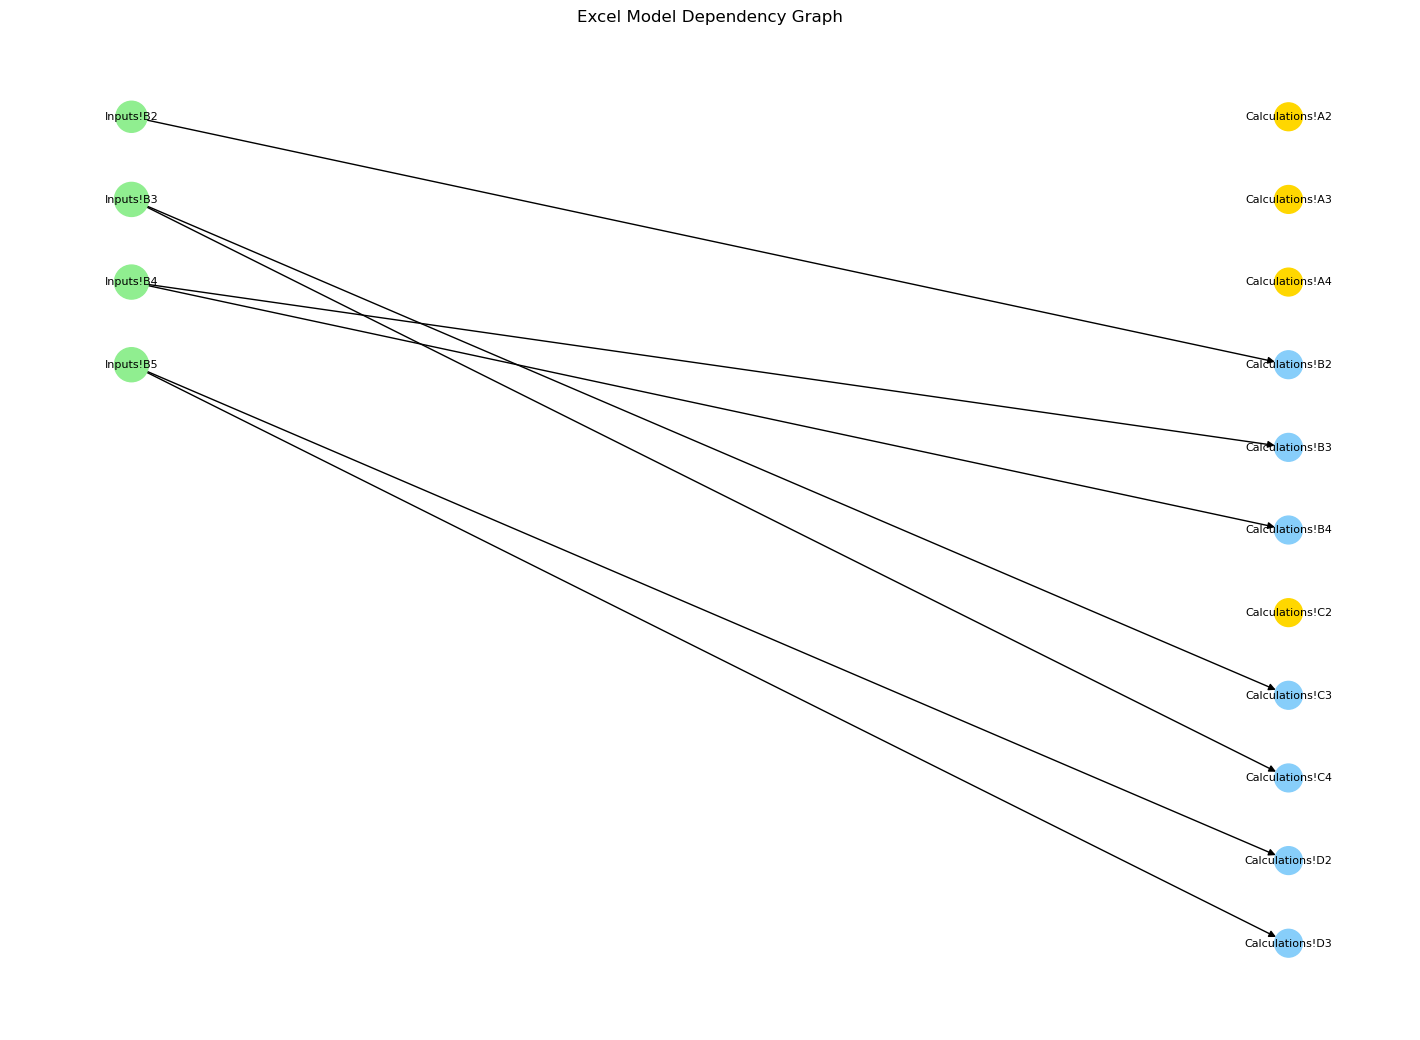

In [10]:
# Create a figure with specified dimensions (14x10 inches)
plt.figure(figsize=(14,10))

# Calculate node sizes based on the number of descendants
# Each node's size is 400 plus 100 times the number of its descendants
# This makes nodes with more dependencies appear larger
sizes = [400 + len(nx.descendants(G,n))*100 for n in G.nodes]

# Draw the network graph
nx.draw(
    G,                  # The graph to draw
    pos,                # Node positions
    with_labels=True,   # Show node labels
    node_color=colors,  # Use predefined colors for nodes
    node_size=sizes,    # Use calculated sizes for nodes
    font_size=8,        # Set text size for labels
    arrows=True         # Show direction of edges
)

# Add a title to the plot
plt.title("Excel Model Dependency Graph")
# Display the graph
plt.show()


## Detect orphan cells

Cells with no edges can indicate:

• overwritten formulas  
• unused assumptions  
• abandoned calculations


In [11]:
# Find all nodes with no connections (degree = 0) and store them in a list called 'orphans'
orphans = [n for n in G.nodes if G.degree(n) == 0]

# Print a header for the output
print("Orphan cells:")
# Display the list of orphan nodes
print(orphans)

Orphan cells:
['Calculations!A2', 'Calculations!A4', 'Calculations!A3', 'Calculations!C2']
